# NREL EVI-Pro Lite API Demo

This notebook shows how to connect to NREL's EVI-Pro Lite API and explore electric vehicle charging load profiles.

## Overview
The EVI-Pro Lite API provides output from NREL's EVI-Pro model and offers daily (24-hour) fleet-level charging load profiles for customizable electric vehicle scenarios.

**API Documentation**: https://developer.nrel.gov/docs/transportation/evi-pro-lite-v1/  
**GitHub Repository**: https://github.com/NREL/EVI-Pro-Lite

## Requirements
- NREL API Key (sign up at https://developer.nrel.gov/signup/)
- Python packages: requests, pandas, numpy, matplotlib, seaborn

In [30]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
import os
from itertools import product
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("All packages imported successfully!")

All packages imported successfully!


## API Key Setup

Can use the same API key as is used for NREL weather fetching (in .env)

In [31]:
API_KEY = "DEMO_KEY"

print(f"Using API key: {API_KEY[:10]}..." if API_KEY != "DEMO_KEY" else "Using DEMO_KEY (rate limited)")

Using DEMO_KEY (rate limited)


## EVI-Pro Lite API Endpoints

The main endpoint for the EVI-Pro Lite API is:
`https://developer.nrel.gov/api/evi-pro-lite/v1/daily-load-profile`



In [32]:
# Base API endpoint
BASE_URL = "https://developer.nrel.gov/api/evi-pro-lite/v1/daily-load-profile"

def make_api_request(api_key, **params):
    """
    Make a request to the EVI-Pro Lite API
    
    Args:
        api_key: NREL API key
        **params: API parameters
    
    Returns:
        dict: JSON response from API
    """
    # Add API key to parameters
    params['api_key'] = api_key
    
    try:
        response = requests.get(BASE_URL, params=params, timeout=30)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"API request failed: {e}")
        return None
    except json.JSONDecodeError as e:
        print(f"Failed to parse JSON response: {e}")
        return None

print("API request function defined")

API request function defined


## API Parameters Reference

The EVI-Pro Lite API accepts the following parameters to customize charging scenarios:

In [33]:
# Complete parameter options for EVI-Pro Lite API
API_PARAMETERS = {
    'fleet_size': {
        'description': 'Number of vehicles in the fleet',
        'options': [50000, 10000, 1000],
        'default': 10000
    },
    'mean_dvmt': {
        'description': 'Mean daily vehicle miles traveled',
        'options': [45, 35, 25],
        'default': 35
    },
    'temp_c': {
        'description': 'Temperature in Celsius',
        'options': [40, 30, 20, 10, 0, -10, -20],
        'default': 20
    },
    'pev_type': {
        'description': 'Plug-in Electric Vehicle type',
        'options': ['PHEV20', 'PHEV50', 'BEV100', 'BEV250'],
        'default': 'BEV250'
    },
    'pev_dist': {
        'description': 'PEV distribution in fleet',
        'options': ['BEV', 'PHEV', 'EQUAL'],
        'default': 'BEV'
    },
    'class_dist': {
        'description': 'Vehicle class distribution',
        'options': ['Sedan', 'SUV', 'Equal'],
        'default': 'Equal'
    },
    'home_access_dist': {
        'description': 'Home charging access distribution',
        'options': ['HA100', 'HA75', 'HA50'],
        'default': 'HA75'
    },
    'home_power_dist': {
        'description': 'Home charging power distribution',
        'options': ['MostL1', 'MostL2', 'Equal'],
        'default': 'MostL2'
    },
    'work_power_dist': {
        'description': 'Work charging power distribution',
        'options': ['MostL1', 'MostL2', 'Equal'],
        'default': 'MostL2'
    },
    'pref_dist': {
        'description': 'Charging preference distribution',
        'options': ['Home60', 'Home80', 'Home100'],
        'default': 'Home80'
    },
    'res_charging': {
        'description': 'Residential charging behavior',
        'options': ['min_delay', 'max_delay', 'midnight_charge'],
        'default': 'min_delay'
    },
    'work_charging': {
        'description': 'Work charging behavior',
        'options': ['min_delay', 'max_delay'],
        'default': 'min_delay'
    }
}

# Display parameter reference
print("EVI-Pro Lite API Parameters:")
print("=" * 50)
for param, info in API_PARAMETERS.items():
    print(f"\n{param}:")
    print(f"   Description: {info['description']}")
    print(f"   Options: {info['options']}")
    print(f"   Default: {info['default']}")

EVI-Pro Lite API Parameters:

fleet_size:
   Description: Number of vehicles in the fleet
   Options: [50000, 10000, 1000]
   Default: 10000

mean_dvmt:
   Description: Mean daily vehicle miles traveled
   Options: [45, 35, 25]
   Default: 35

temp_c:
   Description: Temperature in Celsius
   Options: [40, 30, 20, 10, 0, -10, -20]
   Default: 20

pev_type:
   Description: Plug-in Electric Vehicle type
   Options: ['PHEV20', 'PHEV50', 'BEV100', 'BEV250']
   Default: BEV250

pev_dist:
   Description: PEV distribution in fleet
   Options: ['BEV', 'PHEV', 'EQUAL']
   Default: BEV

class_dist:
   Description: Vehicle class distribution
   Options: ['Sedan', 'SUV', 'Equal']
   Default: Equal

home_access_dist:
   Description: Home charging access distribution
   Options: ['HA100', 'HA75', 'HA50']
   Default: HA75

home_power_dist:
   Description: Home charging power distribution
   Options: ['MostL1', 'MostL2', 'Equal']
   Default: MostL2

work_power_dist:
   Description: Work charging power

## Setup

In [34]:
# Test API connectivity with default parameters
default_params = {param: info['default'] for param, info in API_PARAMETERS.items()}

print("Testing API with default parameters...")
print(f"Parameters: {default_params}")

test_response = make_api_request(API_KEY, **default_params)

if test_response:
    print("\nAPI connection successful!")
    print(f"Response keys: {list(test_response.keys())}")
    
    # Check if we have load profile data
    if 'results' in test_response:
        results = test_response['results']
        print(f"\nResult data keys: {list(results.keys())}")
        
        # Display sample of load profile data
        if 'weekday_load_profile' in results:
            weekday_profiles = results['weekday_load_profile']
            print(f"\nWeekday charging types: {list(weekday_profiles.keys())}")
            first_profile = next(iter(weekday_profiles.values()))
            print(f"Data points per profile: {len(first_profile)}")
            print(f"Sample load values (first 6 points): {first_profile[:6]}")
    else:
        print(f"\nFull response: {test_response}")
else:
    print("API test failed")

Testing API with default parameters...
Parameters: {'fleet_size': 10000, 'mean_dvmt': 35, 'temp_c': 20, 'pev_type': 'BEV250', 'pev_dist': 'BEV', 'class_dist': 'Equal', 'home_access_dist': 'HA75', 'home_power_dist': 'MostL2', 'work_power_dist': 'MostL2', 'pref_dist': 'Home80', 'res_charging': 'min_delay', 'work_charging': 'min_delay'}

API connection successful!
Response keys: ['metadata', 'results']

Result data keys: ['weekday_load_profile', 'weekend_load_profile']

Weekday charging types: ['home_l1', 'home_l2', 'work_l1', 'work_l2', 'public_l2', 'public_l3']
Data points per profile: 96
Sample load values (first 6 points): [812.35, 806.25, 795.33, 767.64, 736.03, 704.97]


## Visualize

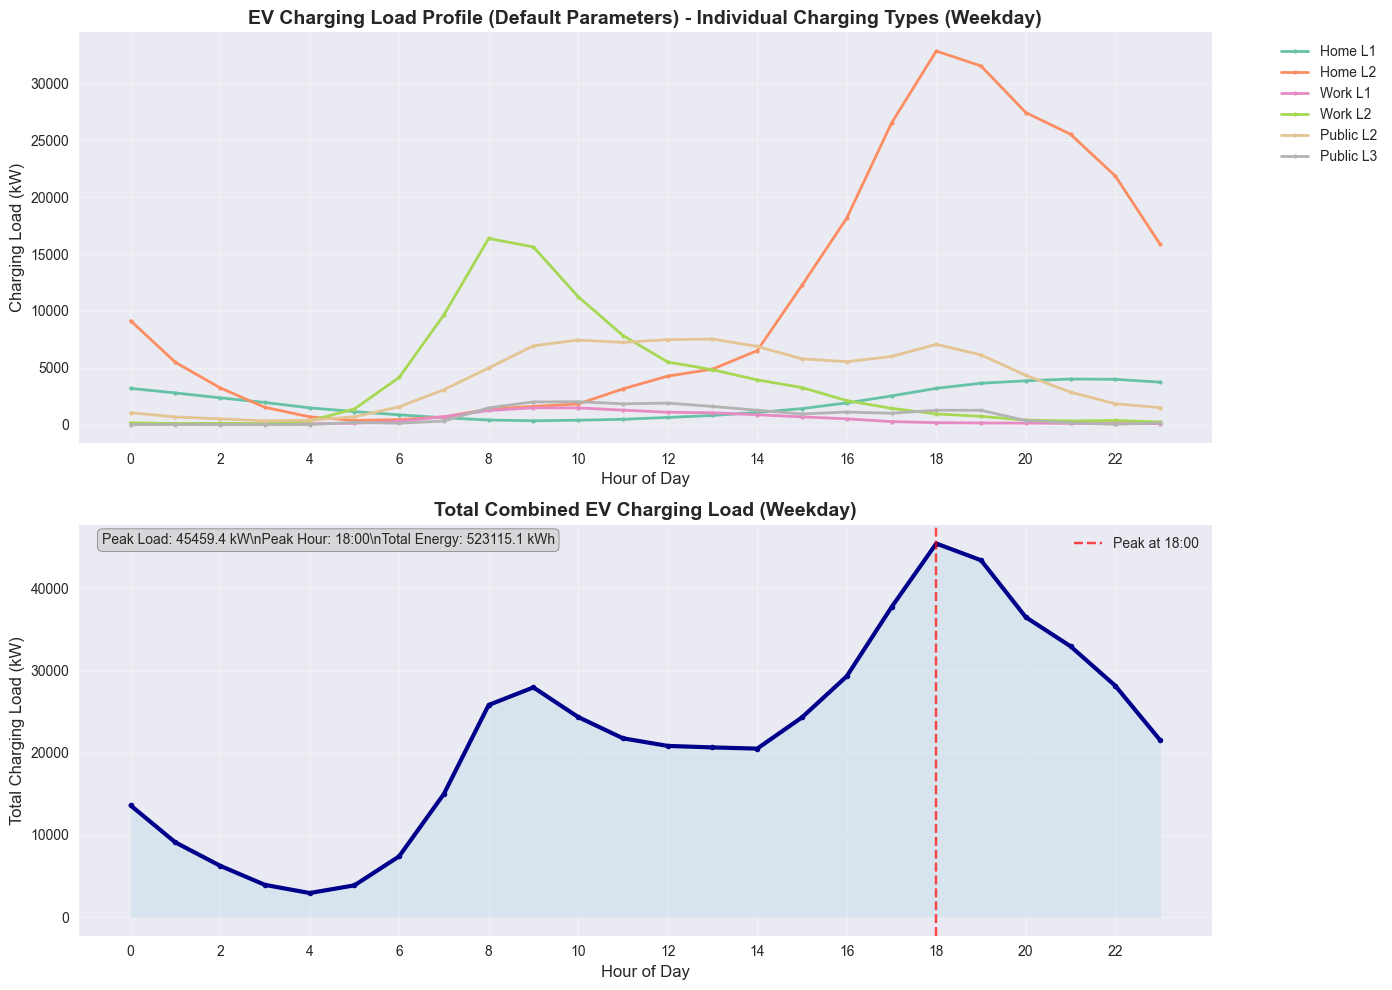

Peak charging load: 45459.4 kW at 18:00
Total daily energy: 523115.1 kWh
\nCharging breakdown (weekday):
  Home L1: 46588.7 kWh total, 4004.0 kW peak
  Home L2: 257111.1 kWh total, 32864.1 kW peak
  Work L1: 11992.0 kWh total, 1473.4 kW peak
  Work L2: 90950.0 kWh total, 16370.1 kW peak
  Public L2: 97628.7 kWh total, 7524.8 kW peak
  Public L3: 18844.5 kWh total, 2007.9 kW peak


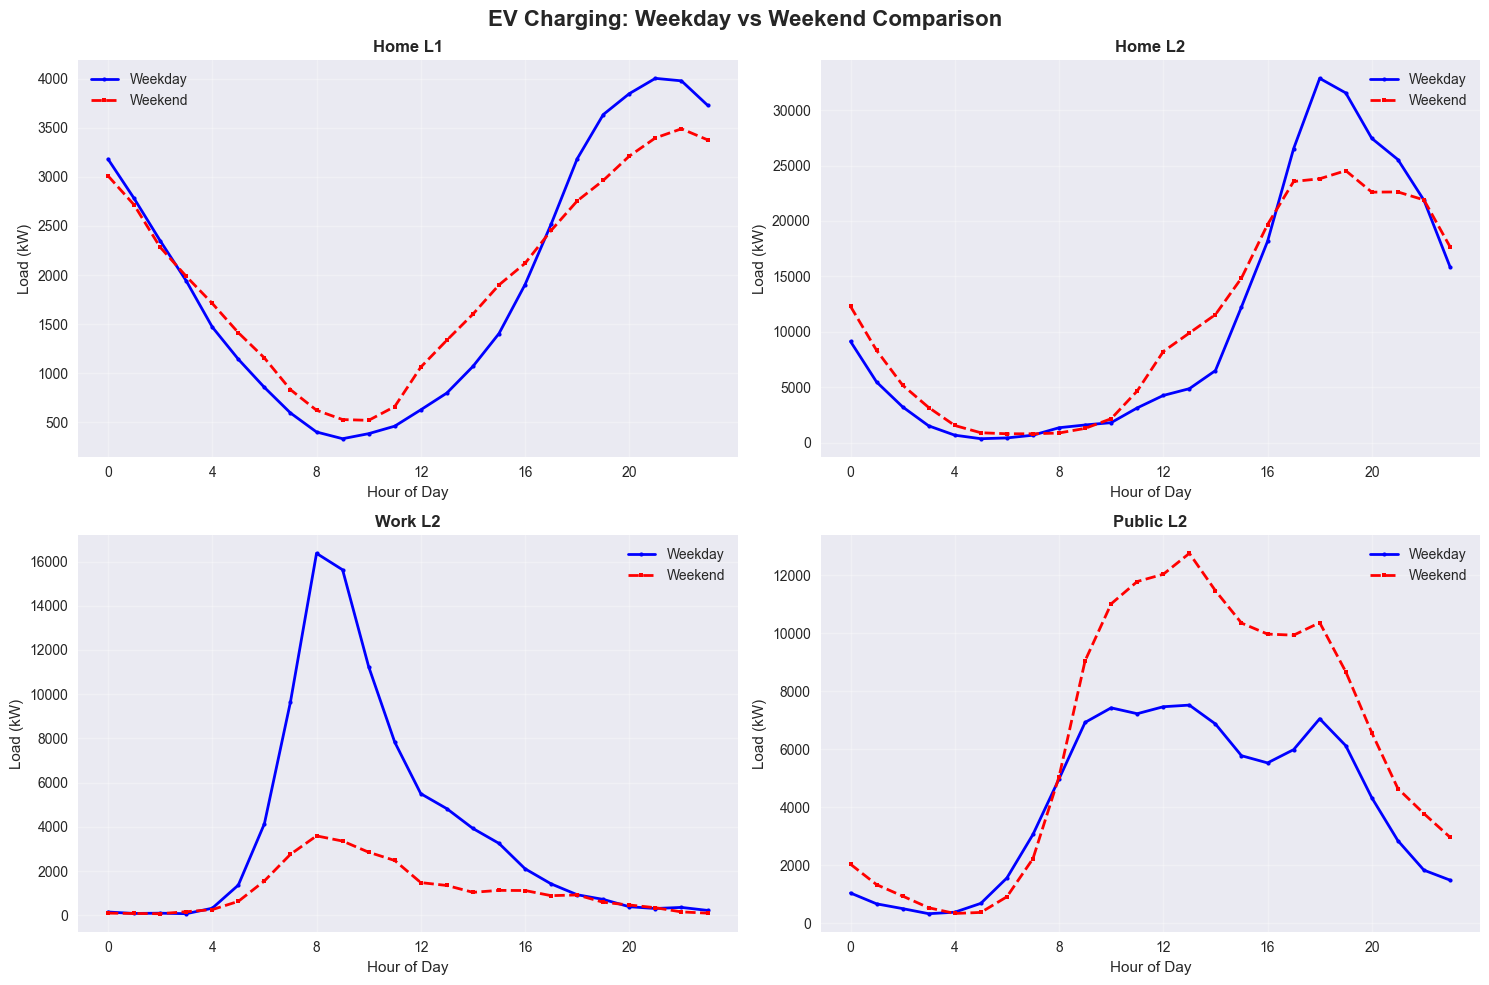

In [35]:
def plot_load_profile(api_response, title="EV Charging Load Profile", day_type="weekday", charging_locations=None):
    """
    Plot the charging load profile from API response
    
    Args:
        api_response: JSON response from EVI-Pro Lite API
        title: Plot title
        day_type: 'weekday' or 'weekend' 
        charging_locations: List of charging types to plot, or None for all
    """
    if not api_response or 'results' not in api_response:
        print("No valid data to plot")
        return
    
    results = api_response['results']
    profile_key = f"{day_type}_load_profile"
    
    if profile_key not in results:
        print(f"No {day_type} load profile data in response")
        return
    
    load_profiles = results[profile_key]
    
    # Default to all charging locations if none specified
    if charging_locations is None:
        charging_locations = list(load_profiles.keys())
    
    # Get the length of profiles from the first available profile
    first_profile = next(iter(load_profiles.values()))
    profile_length = len(first_profile)
    
    # Create the plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Initialize total profile with correct length
    total_profile = [0] * profile_length
    
    # Plot 1: Individual charging types
    colors = plt.cm.Set2(np.linspace(0, 1, len(charging_locations)))
    
    for i, location in enumerate(charging_locations):
        if location in load_profiles:
            profile = load_profiles[location]
            
            # Add to total profile
            for j in range(len(profile)):
                total_profile[j] += profile[j]
            
            # Convert to hourly intervals if needed (assuming 15-minute data)
            if len(profile) == 96:  # 15-minute intervals
                hourly_profile = [sum(profile[j:j+4]) for j in range(0, 96, 4)]
                hours = list(range(24))
            else:
                hourly_profile = profile
                hours = list(range(len(profile)))
            
            ax1.plot(hours, hourly_profile, marker='o', linewidth=2, markersize=3, 
                    color=colors[i], label=location.replace('_', ' ').title())
    
    ax1.set_title(f'{title} - Individual Charging Types ({day_type.title()})', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Hour of Day', fontsize=12)
    ax1.set_ylabel('Charging Load (kW)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.set_xticks(range(0, 24, 2) if len(hours) == 24 else range(0, len(hours), max(1, len(hours)//12)))
    
    # Plot 2: Total combined load
    if len(total_profile) == 96:  # Convert to hourly
        hourly_total = [sum(total_profile[j:j+4]) for j in range(0, 96, 4)]
        hours_total = list(range(24))
    else:
        hourly_total = total_profile
        hours_total = list(range(len(total_profile)))
    
    ax2.plot(hours_total, hourly_total, marker='o', linewidth=3, markersize=4, color='darkblue')
    ax2.fill_between(hours_total, hourly_total, alpha=0.3, color='lightblue')
    
    # Add statistics
    max_load = max(hourly_total)
    max_hour = hourly_total.index(max_load)
    total_energy = sum(hourly_total)
    
    ax2.axvline(x=max_hour, color='red', linestyle='--', alpha=0.7, label=f'Peak at {max_hour}:00')
    ax2.legend()
    
    ax2.set_title(f'Total Combined EV Charging Load ({day_type.title()})', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Hour of Day', fontsize=12)
    ax2.set_ylabel('Total Charging Load (kW)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(range(0, 24, 2) if len(hours_total) == 24 else range(0, len(hours_total), max(1, len(hours_total)//12)))
    
    # Add text box with statistics
    stats_text = f'Peak Load: {max_load:.1f} kW\\nPeak Hour: {max_hour}:00\\nTotal Energy: {total_energy:.1f} kWh'
    ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    print(f"Peak charging load: {max_load:.1f} kW at {max_hour}:00")
    print(f"Total daily energy: {total_energy:.1f} kWh")
    
    # Print breakdown by charging type
    print(f"\\nCharging breakdown ({day_type}):")
    for location in charging_locations:
        if location in load_profiles:
            profile = load_profiles[location]
            if len(profile) == 96:
                hourly_profile = [sum(profile[j:j+4]) for j in range(0, 96, 4)]
            else:
                hourly_profile = profile
            location_total = sum(hourly_profile)
            location_peak = max(hourly_profile)
            print(f"  {location.replace('_', ' ').title()}: {location_total:.1f} kWh total, {location_peak:.1f} kW peak")

def compare_weekday_weekend(api_response, title="EV Charging: Weekday vs Weekend"):
    """
    Compare weekday and weekend charging patterns
    """
    if not api_response or 'results' not in api_response:
        print("No valid data to plot")
        return
    
    results = api_response['results']
    
    if 'weekday_load_profile' not in results or 'weekend_load_profile' not in results:
        print("Missing weekday or weekend data")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    charging_types = ['home_l1', 'home_l2', 'work_l2', 'public_l2']
    
    for i, charging_type in enumerate(charging_types[:4]):
        row, col = i // 2, i % 2
        
        if charging_type in results['weekday_load_profile'] and charging_type in results['weekend_load_profile']:
            weekday_profile = results['weekday_load_profile'][charging_type]
            weekend_profile = results['weekend_load_profile'][charging_type]
            
            # Convert to hourly if needed
            if len(weekday_profile) == 96:
                weekday_hourly = [sum(weekday_profile[j:j+4]) for j in range(0, 96, 4)]
                weekend_hourly = [sum(weekend_profile[j:j+4]) for j in range(0, 96, 4)]
                hours = list(range(24))
            else:
                weekday_hourly = weekday_profile
                weekend_hourly = weekend_profile
                hours = list(range(len(weekday_profile)))
            
            axes[row, col].plot(hours, weekday_hourly, 'b-', linewidth=2, label='Weekday', marker='o', markersize=3)
            axes[row, col].plot(hours, weekend_hourly, 'r--', linewidth=2, label='Weekend', marker='s', markersize=3)
            axes[row, col].set_title(f'{charging_type.replace("_", " ").title()}', fontweight='bold')
            axes[row, col].set_xlabel('Hour of Day')
            axes[row, col].set_ylabel('Load (kW)')
            axes[row, col].grid(True, alpha=0.3)
            axes[row, col].legend()
            axes[row, col].set_xticks(range(0, 24, 4) if len(hours) == 24 else range(0, len(hours), max(1, len(hours)//6)))
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Plot the test response with updated function
if test_response:
    plot_load_profile(test_response, "EV Charging Load Profile (Default Parameters)", day_type="weekday")
    compare_weekday_weekend(test_response, "EV Charging: Weekday vs Weekend Comparison")
else:
    print("No test response available to plot")

## Parameter Exploration

In [36]:
def compare_parameters(base_params, param_to_vary, values_to_test, api_key):
    """
    Compare load profiles by varying a single parameter
    
    Args:
        base_params: Base parameter set
        param_to_vary: Parameter name to vary
        values_to_test: List of values to test for the parameter
        api_key: NREL API key
    """
    plt.figure(figsize=(14, 8))
    
    results = {}
    
    for value in values_to_test:
        # Create parameters with varied value
        test_params = base_params.copy()
        test_params[param_to_vary] = value
        
        print(f"Testing {param_to_vary} = {value}...")
        response = make_api_request(api_key, **test_params)
        
        if response and 'results' in response and 'weekday_load_profile' in response['results']:
            # Calculate total load by summing all charging types
            weekday_profiles = response['results']['weekday_load_profile']
            
            # Sum all charging location profiles for total load
            total_profile = None
            for location, profile in weekday_profiles.items():
                if total_profile is None:
                    total_profile = profile.copy()
                else:
                    total_profile = [t + p for t, p in zip(total_profile, profile)]
            
            if total_profile:
                # Convert to hourly if needed (96 15-minute intervals -> 24 hours)
                if len(total_profile) == 96:
                    hourly_profile = [sum(total_profile[j:j+4]) for j in range(0, 96, 4)]
                    hours = list(range(24))
                else:
                    hourly_profile = total_profile
                    hours = list(range(len(total_profile)))
                
                results[value] = hourly_profile
                
                # Plot this profile
                plt.plot(hours, hourly_profile, marker='o', linewidth=2, 
                        markersize=3, label=f'{param_to_vary}={value}')
        else:
            print(f"Failed to get data for {param_to_vary} = {value}")
    
    if results:
        plt.title(f'Total EV Charging Load Profiles - Varying {param_to_vary}', fontsize=16, fontweight='bold')
        plt.xlabel('Hour of Day', fontsize=12)
        plt.ylabel('Total Charging Load (kW)', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.xticks(range(0, 24, 2) if len(hours) == 24 else range(0, len(hours), max(1, len(hours)//12)))
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        print(f"\\nSummary for {param_to_vary} comparison:")
        for value, profile in results.items():
            peak_load = max(profile)
            total_energy = sum(profile)
            peak_hour = profile.index(peak_load)
            print(f"  {value}: Peak = {peak_load:.1f} kW at {peak_hour}:00, Total = {total_energy:.1f} kWh")
    else:
        print(f"No successful API calls for {param_to_vary} comparison")
    
    return results

def extract_total_load_profile(api_response, day_type="weekday"):
    """
    Extract total load profile from API response by summing all charging types
    
    Args:
        api_response: API response dictionary
        day_type: 'weekday' or 'weekend'
    
    Returns:
        list: Total hourly load profile
    """
    if not api_response or 'results' not in api_response:
        return None
    
    results = api_response['results']
    profile_key = f"{day_type}_load_profile"
    
    if profile_key not in results:
        return None
    
    profiles = results[profile_key]
    total_profile = None
    
    for location, profile in profiles.items():
        if total_profile is None:
            total_profile = profile.copy()
        else:
            total_profile = [t + p for t, p in zip(total_profile, profile)]
    
    if total_profile and len(total_profile) == 96:
        # Convert 15-minute intervals to hourly
        return [sum(total_profile[j:j+4]) for j in range(0, 96, 4)]
    
    return total_profile

print("Updated parameter comparison function defined")

Updated parameter comparison function defined


### Temperature Impact Analysis

Testing temp_c = -10...
Testing temp_c = 0...
Testing temp_c = 20...
Testing temp_c = 40...


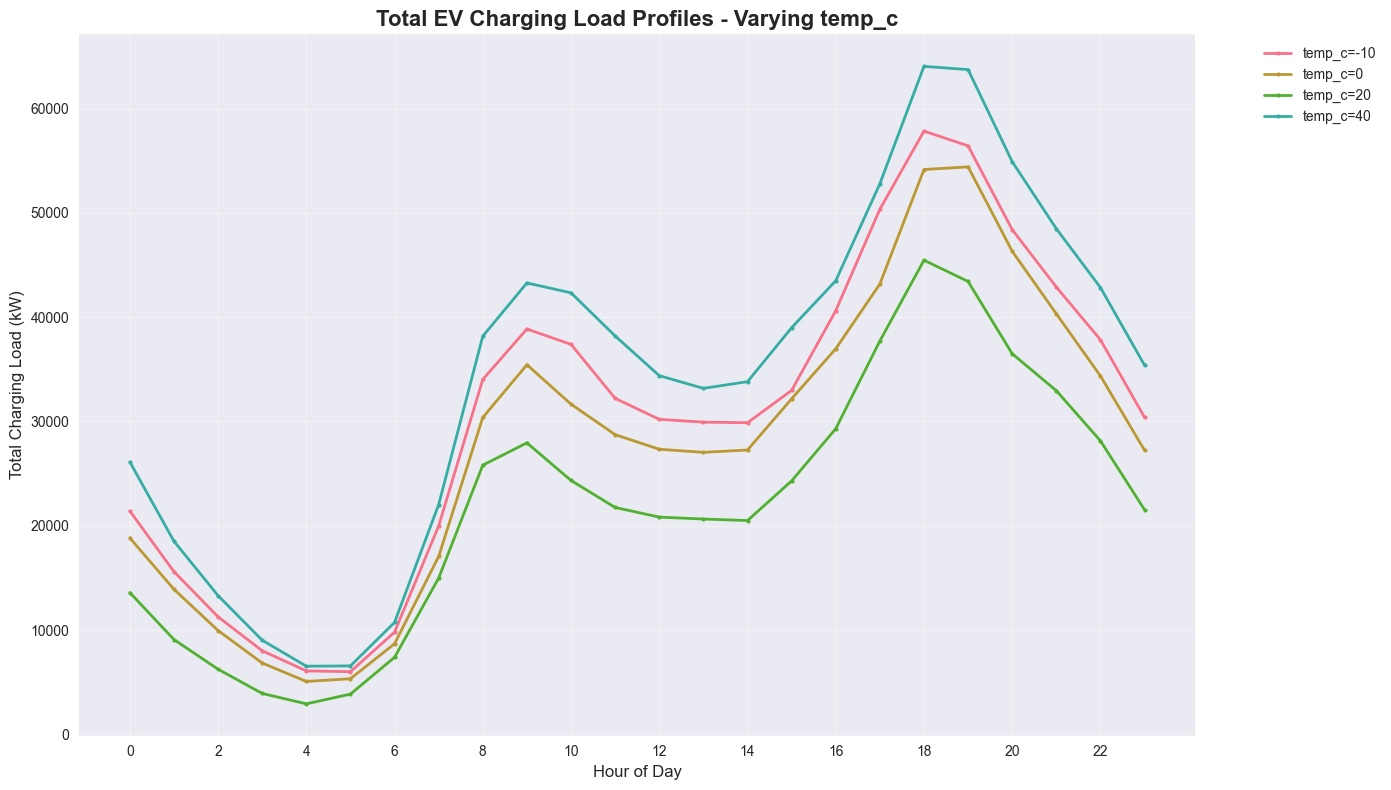

\nSummary for temp_c comparison:
  -10: Peak = 57840.9 kW at 18:00, Total = 728353.8 kWh
  0: Peak = 54409.9 kW at 19:00, Total = 662624.5 kWh
  20: Peak = 45459.4 kW at 18:00, Total = 523115.1 kWh
  40: Peak = 64047.4 kW at 18:00, Total = 820814.3 kWh


In [37]:
# Test different temperatures
temp_results = compare_parameters(
    base_params=default_params,
    param_to_vary='temp_c',
    values_to_test=[-10, 0, 20, 40],  # Cold to hot temperatures
    api_key=API_KEY
)

### Vehicle Type Impact Analysis

Testing pev_type = PHEV20...
Testing pev_type = PHEV50...
Testing pev_type = BEV100...
Testing pev_type = BEV250...


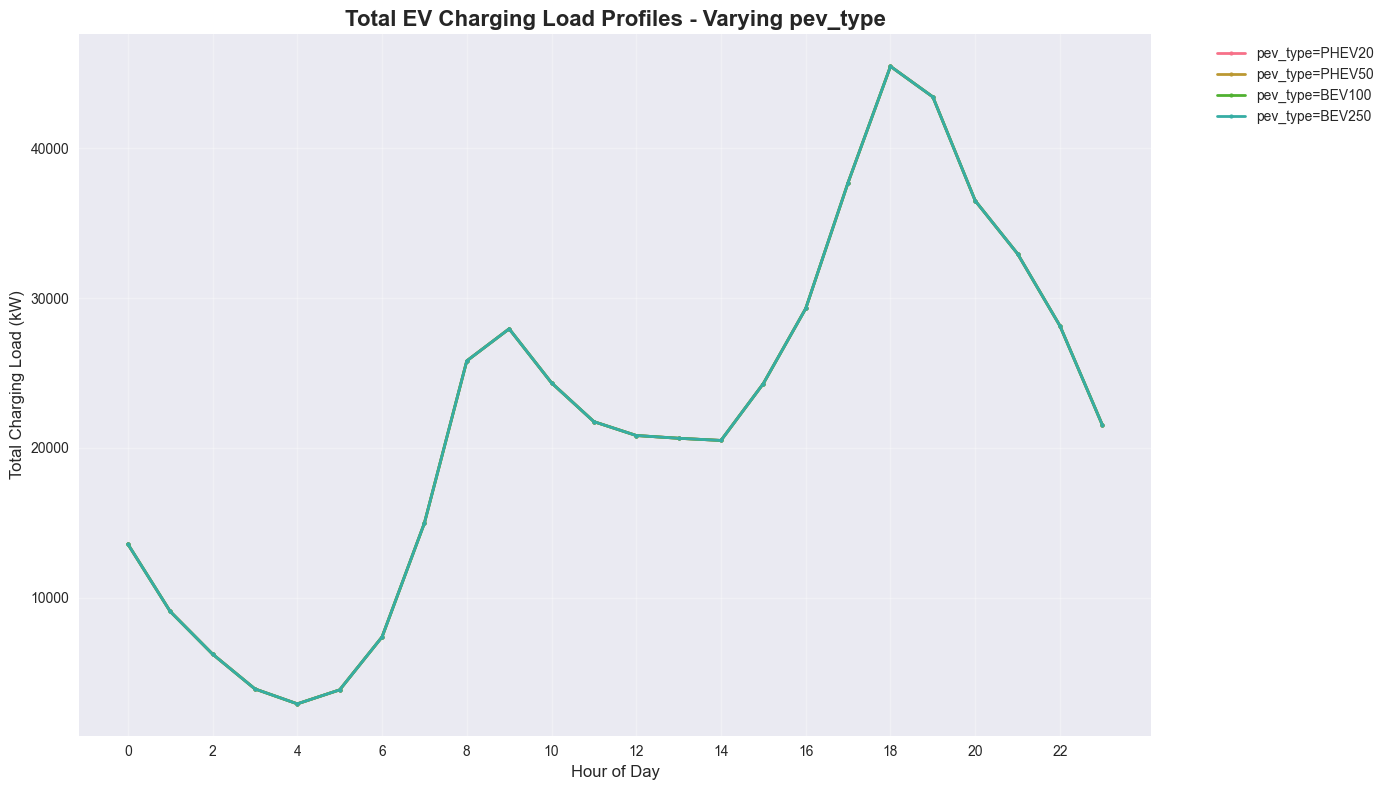

\nSummary for pev_type comparison:
  PHEV20: Peak = 45459.4 kW at 18:00, Total = 523115.1 kWh
  PHEV50: Peak = 45459.4 kW at 18:00, Total = 523115.1 kWh
  BEV100: Peak = 45459.4 kW at 18:00, Total = 523115.1 kWh
  BEV250: Peak = 45459.4 kW at 18:00, Total = 523115.1 kWh


In [38]:
# Test different PEV types
pev_results = compare_parameters(
    base_params=default_params,
    param_to_vary='pev_type',
    values_to_test=['PHEV20', 'PHEV50', 'BEV100', 'BEV250'],
    api_key=API_KEY
)

### Charging Behavior Impact Analysis

Testing res_charging = min_delay...
Testing res_charging = max_delay...
Testing res_charging = midnight_charge...
API request failed: 400 Client Error: Bad Request for url: https://developer.nrel.gov/api/evi-pro-lite/v1/daily-load-profile?fleet_size=10000&mean_dvmt=35&temp_c=20&pev_type=BEV250&pev_dist=BEV&class_dist=Equal&home_access_dist=HA75&home_power_dist=MostL2&work_power_dist=MostL2&pref_dist=Home80&res_charging=midnight_charge&work_charging=min_delay&api_key=DEMO_KEY
Failed to get data for res_charging = midnight_charge


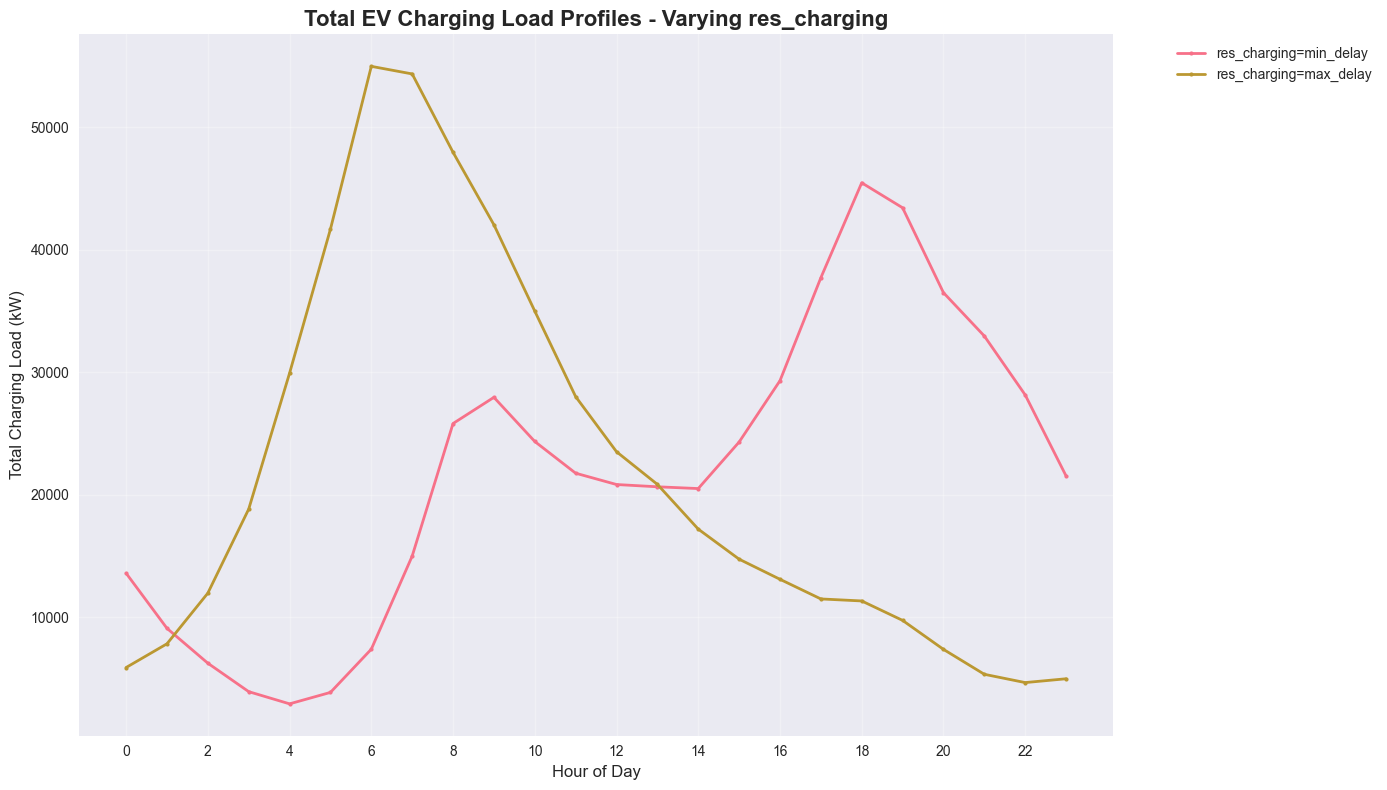

\nSummary for res_charging comparison:
  min_delay: Peak = 45459.4 kW at 18:00, Total = 523115.1 kWh
  max_delay: Peak = 54966.5 kW at 6:00, Total = 522630.9 kWh


In [39]:
# Test different residential charging behaviors
charging_results = compare_parameters(
    base_params=default_params,
    param_to_vary='res_charging',
    values_to_test=['min_delay', 'max_delay', 'midnight_charge'],
    api_key=API_KEY
)

## California-Specific Analysis

Let's create scenarios relevant to California's climate and EV adoption patterns:

Running California-specific EV charging scenarios...

Running scenario: Bay Area Summer
   Key parameters: {'temp_c': 20, 'pev_type': 'BEV250', 'pev_dist': 'BEV', 'home_access_dist': 'HA75', 'res_charging': 'max_delay', 'mean_dvmt': 35}
   Peak load: 54966.5 kW
   Total energy: 522630.9 kWh
   Charging breakdown:
     Home L1: 47649.6 kWh (9.1%)
     Home L2: 261306.0 kWh (50.0%)
     Work L1: 11562.7 kWh (2.2%)
     Work L2: 87274.8 kWh (16.7%)
     Public L2: 97729.5 kWh (18.7%)
     Public L3: 17108.4 kWh (3.3%)

Running scenario: LA Basin Winter
   Key parameters: {'temp_c': 10, 'pev_type': 'BEV250', 'pev_dist': 'BEV', 'home_access_dist': 'HA50', 'res_charging': 'min_delay', 'mean_dvmt': 45}
   Peak load: 51609.6 kW
   Total energy: 704903.6 kWh
   Charging breakdown:
     Home L1: 37205.1 kWh (5.3%)
     Home L2: 227552.5 kWh (32.3%)
     Work L1: 19505.9 kWh (2.8%)
     Work L2: 163687.8 kWh (23.2%)
     Public L2: 193608.9 kWh (27.5%)
     Public L3: 63343.5 kWh (9.0%)

Running 

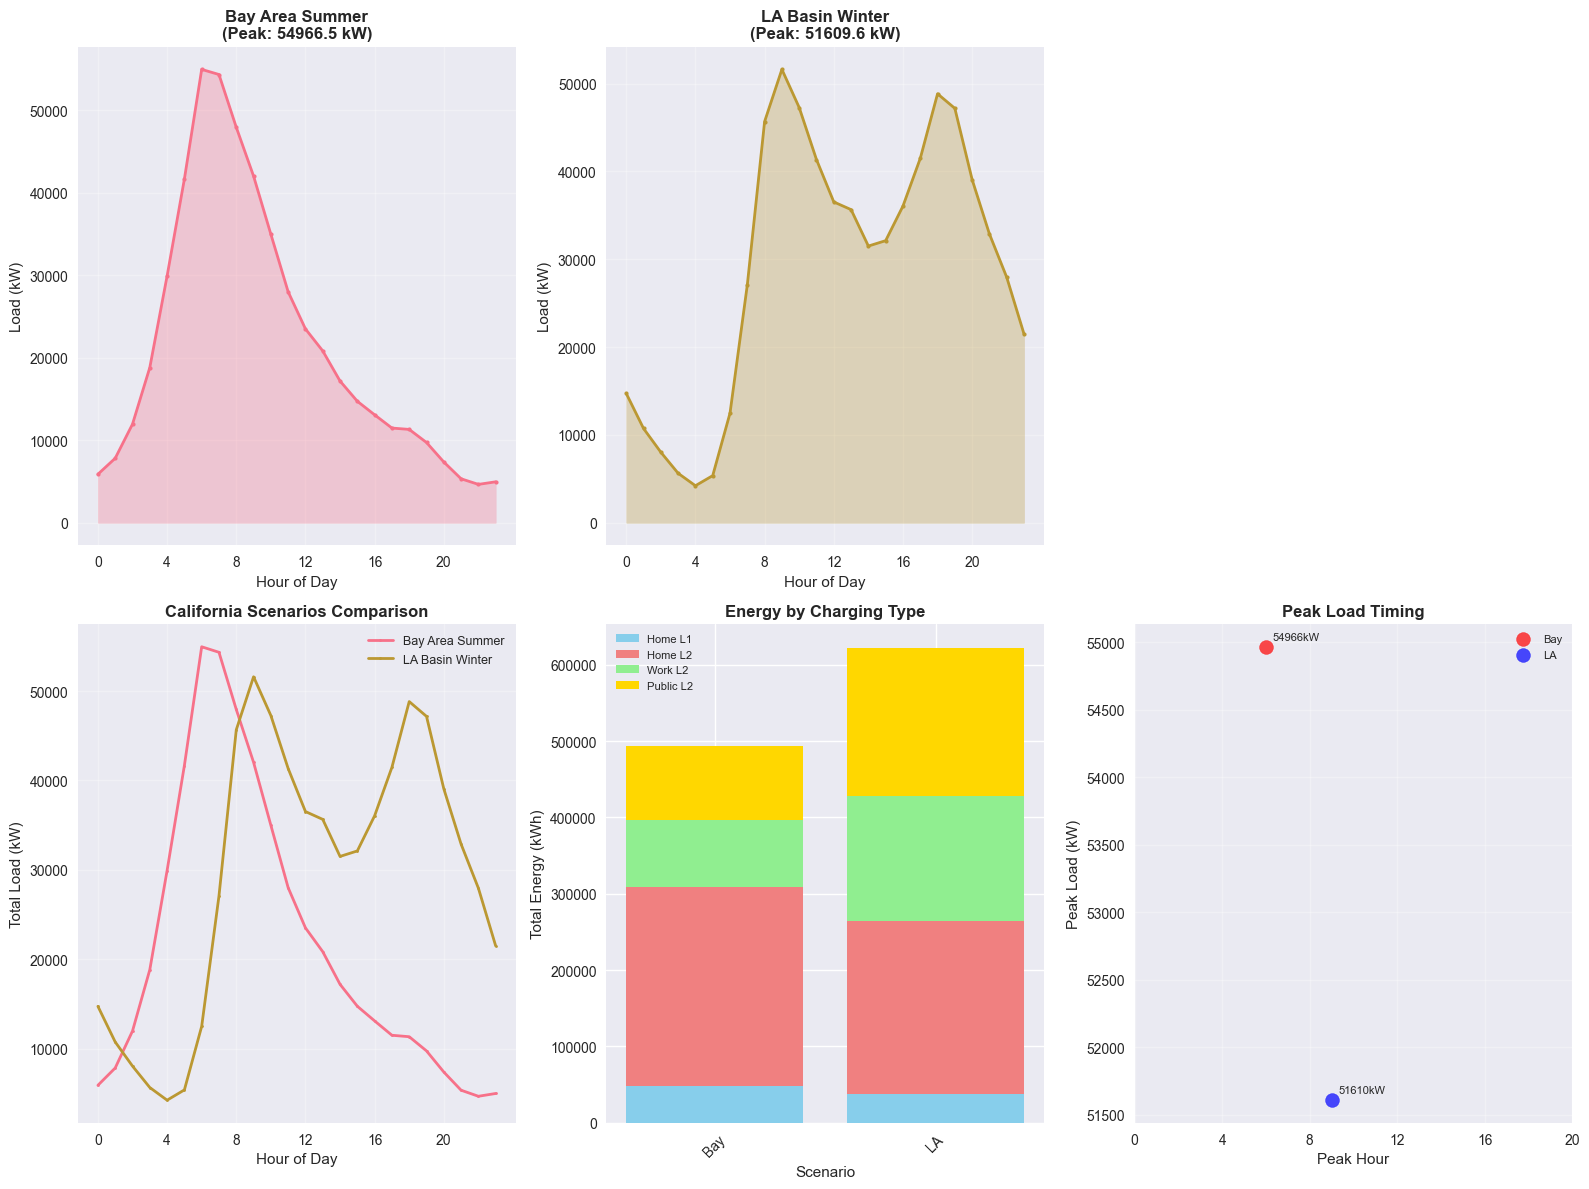


Completed 2 California scenarios

California Scenarios Summary:
       Scenario  Temperature (°C) Vehicle Type Home Access Charging Behavior  Daily Miles  Peak Load (kW)  Peak Hour  Total Energy (kWh)
Bay Area Summer                20       BEV250        HA75         max_delay           35        54966.48          6           522630.89
LA Basin Winter                10       BEV250        HA50         min_delay           45        51609.56          9           704903.63


In [40]:
# Define California-specific scenarios
california_scenarios = {
    'Bay Area Summer': {
        'temp_c': 20,
        'pev_type': 'BEV250',
        'pev_dist': 'BEV',
        'home_access_dist': 'HA75',
        'res_charging': 'max_delay',  # Time of use rates encourage delayed charging
        'mean_dvmt': 35
    },
    'LA Basin Winter': {
        'temp_c': 10,
        'pev_type': 'BEV250',
        'pev_dist': 'BEV',
        'home_access_dist': 'HA50',  # Lower home access due to apartments
        'res_charging': 'min_delay',
        'mean_dvmt': 45  # Higher driving in LA
    },
    'Central Valley Summer': {
        'temp_c': 40,  # Very hot summers
        'pev_type': 'BEV100',
        'pev_dist': 'EQUAL',
        'home_access_dist': 'HA100',  # More single-family homes
        'res_charging': 'midnight_charge',  # Avoid peak demand
        'mean_dvmt': 45
    }
}

# Run California scenarios
print("Running California-specific EV charging scenarios...")

ca_results = {}
plt.figure(figsize=(16, 12))

for i, (scenario_name, scenario_params) in enumerate(california_scenarios.items()):
    # Merge with default params
    full_params = default_params.copy()
    full_params.update(scenario_params)
    
    print(f"\nRunning scenario: {scenario_name}")
    print(f"   Key parameters: {scenario_params}")
    
    response = make_api_request(API_KEY, **full_params)
    
    if response and 'results' in response and 'weekday_load_profile' in response['results']:
        # Extract total load profile
        total_profile = extract_total_load_profile(response, "weekday")
        
        if total_profile:
            ca_results[scenario_name] = {
                'profile': total_profile,
                'params': scenario_params,
                'response': response
            }
            
            # Create subplot for each scenario
            plt.subplot(2, 3, i+1)
            hours = list(range(24))
            plt.plot(hours, total_profile, marker='o', linewidth=2, markersize=3, color=f'C{i}')
            plt.fill_between(hours, total_profile, alpha=0.3, color=f'C{i}')
            plt.title(f'{scenario_name}\n(Peak: {max(total_profile):.1f} kW)', fontsize=12, fontweight='bold')
            plt.xlabel('Hour of Day')
            plt.ylabel('Load (kW)')
            plt.grid(True, alpha=0.3)
            plt.xticks(range(0, 24, 4))
            
            print(f"   Peak load: {max(total_profile):.1f} kW")
            print(f"   Total energy: {sum(total_profile):.1f} kWh")
            
            # Show charging breakdown
            weekday_profiles = response['results']['weekday_load_profile']
            print(f"   Charging breakdown:")
            for location, profile in weekday_profiles.items():
                if len(profile) == 96:
                    hourly_profile = [sum(profile[j:j+4]) for j in range(0, 96, 4)]
                else:
                    hourly_profile = profile
                location_energy = sum(hourly_profile)
                percentage = (location_energy / sum(total_profile)) * 100 if sum(total_profile) > 0 else 0
                print(f"     {location.replace('_', ' ').title()}: {location_energy:.1f} kWh ({percentage:.1f}%)")
        else:
            print(f"   Failed to extract load profile for {scenario_name}")
    else:
        print(f"   Failed to get data for {scenario_name}")

# Add overall comparison plot
if ca_results:
    plt.subplot(2, 3, 4)
    hours = list(range(24))
    for i, (scenario_name, data) in enumerate(ca_results.items()):
        plt.plot(hours, data['profile'], linewidth=2, label=scenario_name, marker='o', markersize=2)

    plt.title('California Scenarios Comparison', fontsize=12, fontweight='bold')
    plt.xlabel('Hour of Day')
    plt.ylabel('Total Load (kW)')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=9)
    plt.xticks(range(0, 24, 4))
    
    # Add charging type breakdown comparison
    plt.subplot(2, 3, 5)
    charging_types = ['home_l1', 'home_l2', 'work_l2', 'public_l2']
    
    scenario_names = list(ca_results.keys())
    x_labels = [name.split()[0] for name in scenario_names]  # Shortened labels
    
    charging_totals = {ct: [] for ct in charging_types}
    
    for scenario_name, data in ca_results.items():
        weekday_profiles = data['response']['results']['weekday_load_profile']
        for ct in charging_types:
            if ct in weekday_profiles:
                profile = weekday_profiles[ct]
                if len(profile) == 96:
                    hourly_profile = [sum(profile[j:j+4]) for j in range(0, 96, 4)]
                else:
                    hourly_profile = profile
                charging_totals[ct].append(sum(hourly_profile))
            else:
                charging_totals[ct].append(0)
    
    # Stacked bar chart
    bottom = [0] * len(scenario_names)
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']
    
    for i, ct in enumerate(charging_types):
        plt.bar(x_labels, charging_totals[ct], bottom=bottom, 
                label=ct.replace('_', ' ').title(), color=colors[i])
        bottom = [b + v for b, v in zip(bottom, charging_totals[ct])]
    
    plt.title('Energy by Charging Type', fontsize=12, fontweight='bold')
    plt.xlabel('Scenario')
    plt.ylabel('Total Energy (kWh)')
    plt.legend(fontsize=8)
    plt.xticks(rotation=45)
    
    # Add peak timing comparison
    plt.subplot(2, 3, 6)
    peak_hours = []
    peak_loads = []
    
    for scenario_name, data in ca_results.items():
        profile = data['profile']
        peak_load = max(profile)
        peak_hour = profile.index(peak_load)
        peak_hours.append(peak_hour)
        peak_loads.append(peak_load)
    
    colors_scatter = ['red', 'blue', 'green']
    for i, (scenario_name, peak_hour, peak_load) in enumerate(zip(scenario_names, peak_hours, peak_loads)):
        plt.scatter(peak_hour, peak_load, s=100, c=colors_scatter[i], label=scenario_name.split()[0], alpha=0.7)
        plt.annotate(f'{peak_load:.0f}kW', (peak_hour, peak_load), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    plt.title('Peak Load Timing', fontsize=12, fontweight='bold')
    plt.xlabel('Peak Hour')
    plt.ylabel('Peak Load (kW)')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.xticks(range(0, 24, 4))

plt.tight_layout()
plt.show()

print(f"\nCompleted {len(ca_results)} California scenarios")

# Save California results to DataFrame for analysis
if ca_results:
    ca_summary = []
    for scenario_name, data in ca_results.items():
        profile = data['profile']
        params = data['params']
        
        summary = {
            'Scenario': scenario_name,
            'Temperature (°C)': params['temp_c'],
            'Vehicle Type': params['pev_type'],
            'Home Access': params['home_access_dist'],
            'Charging Behavior': params['res_charging'],
            'Daily Miles': params['mean_dvmt'],
            'Peak Load (kW)': max(profile),
            'Peak Hour': profile.index(max(profile)),
            'Total Energy (kWh)': sum(profile)
        }
        ca_summary.append(summary)
    
    ca_df = pd.DataFrame(ca_summary)
    print("\nCalifornia Scenarios Summary:")
    print("=" * 80)
    print(ca_df.to_string(index=False))